# Assignment 2: Housing Price Prediction

### Task:

Is dataset par **Linear Regression** apply karni hai aur **Price** ko predict karna hai.

**Target Column (Prediction):**

* `Price`

Baaki numeric columns ko features ke taur par use karein.

### Submission Requirements:

* Complete Jupyter Notebook (.ipynb)
* Dataset
* Proper comments in code
* Model Evaluation (MAE, MSE, RMSE, R² Score)
* Prediction Results

**Submission Deadline:**
**29 July 2026 (29/07/2026)**

Apna complete project GitHub par upload karein aur GitHub repository ka link submit karein.

In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import FunctionTransformer

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [242]:
df = pd.read_csv(r'Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [243]:
df.shape

(545, 13)

In [244]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [245]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [246]:
df.duplicated().sum()

np.int64(0)

In [247]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [248]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [249]:
numerical_columns = df.select_dtypes(include = [int, float]).columns
categorical_columns = df.select_dtypes(include = [object]).columns

In [250]:
print('lenght of numerical columns is'.capitalize(), len(numerical_columns))
print('lenght of categorical columns is'.capitalize(), len(categorical_columns))

Lenght of numerical columns is 6
Lenght of categorical columns is 7


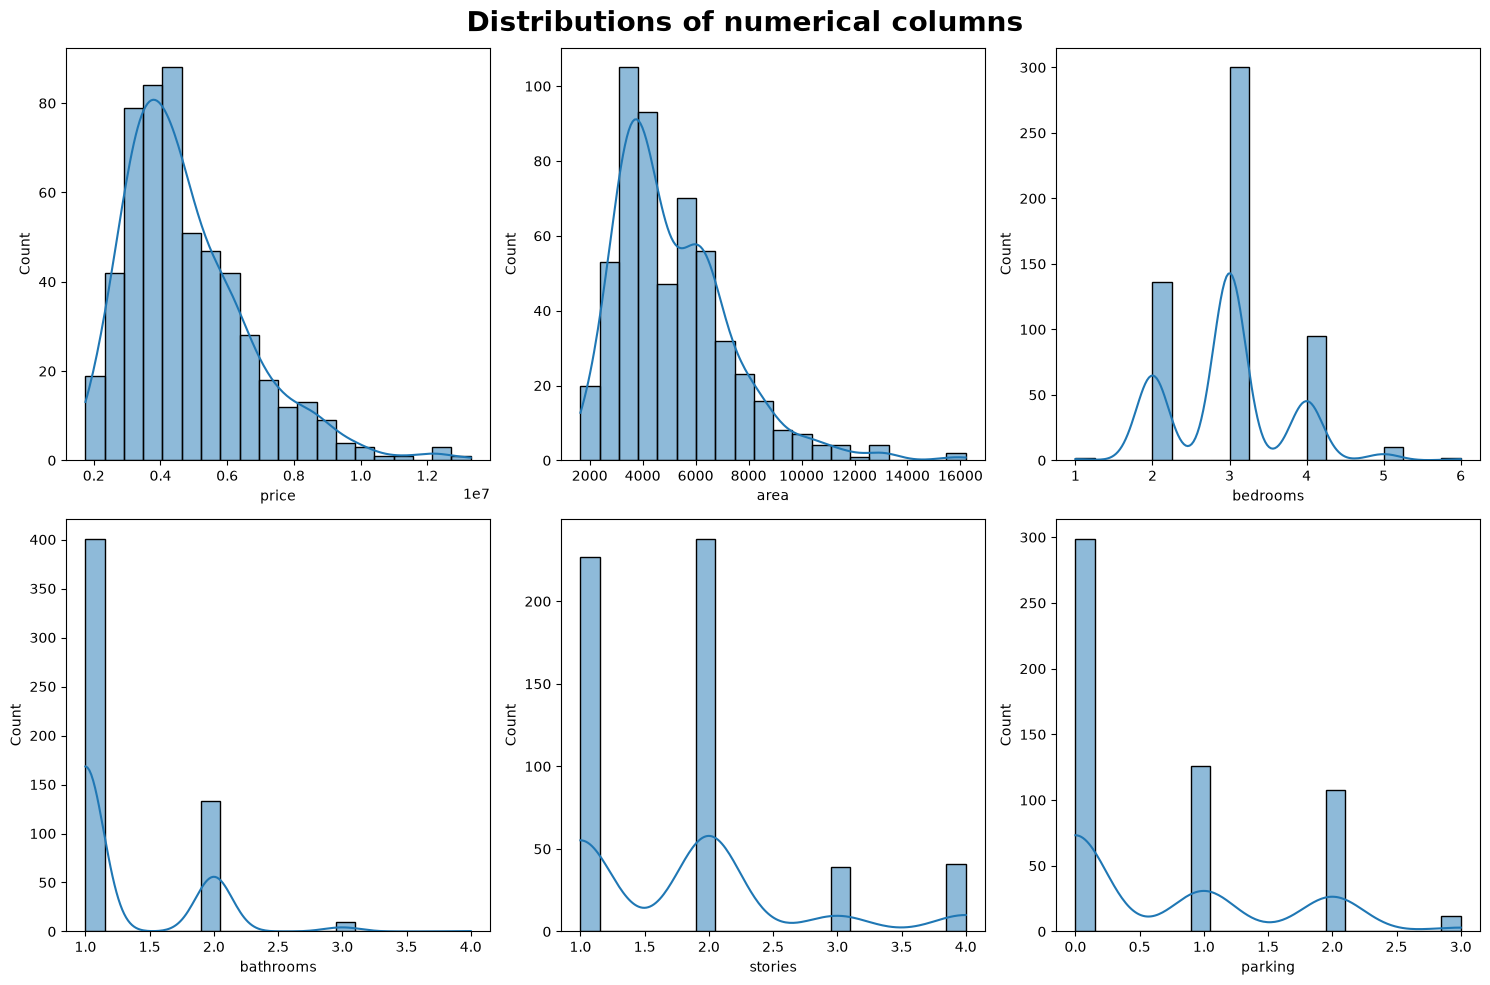

In [251]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.histplot(
        data = df,
        x = col,
        bins = 20,
        kde = True,
        ax = ax
    )

plt.suptitle('Distributions of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

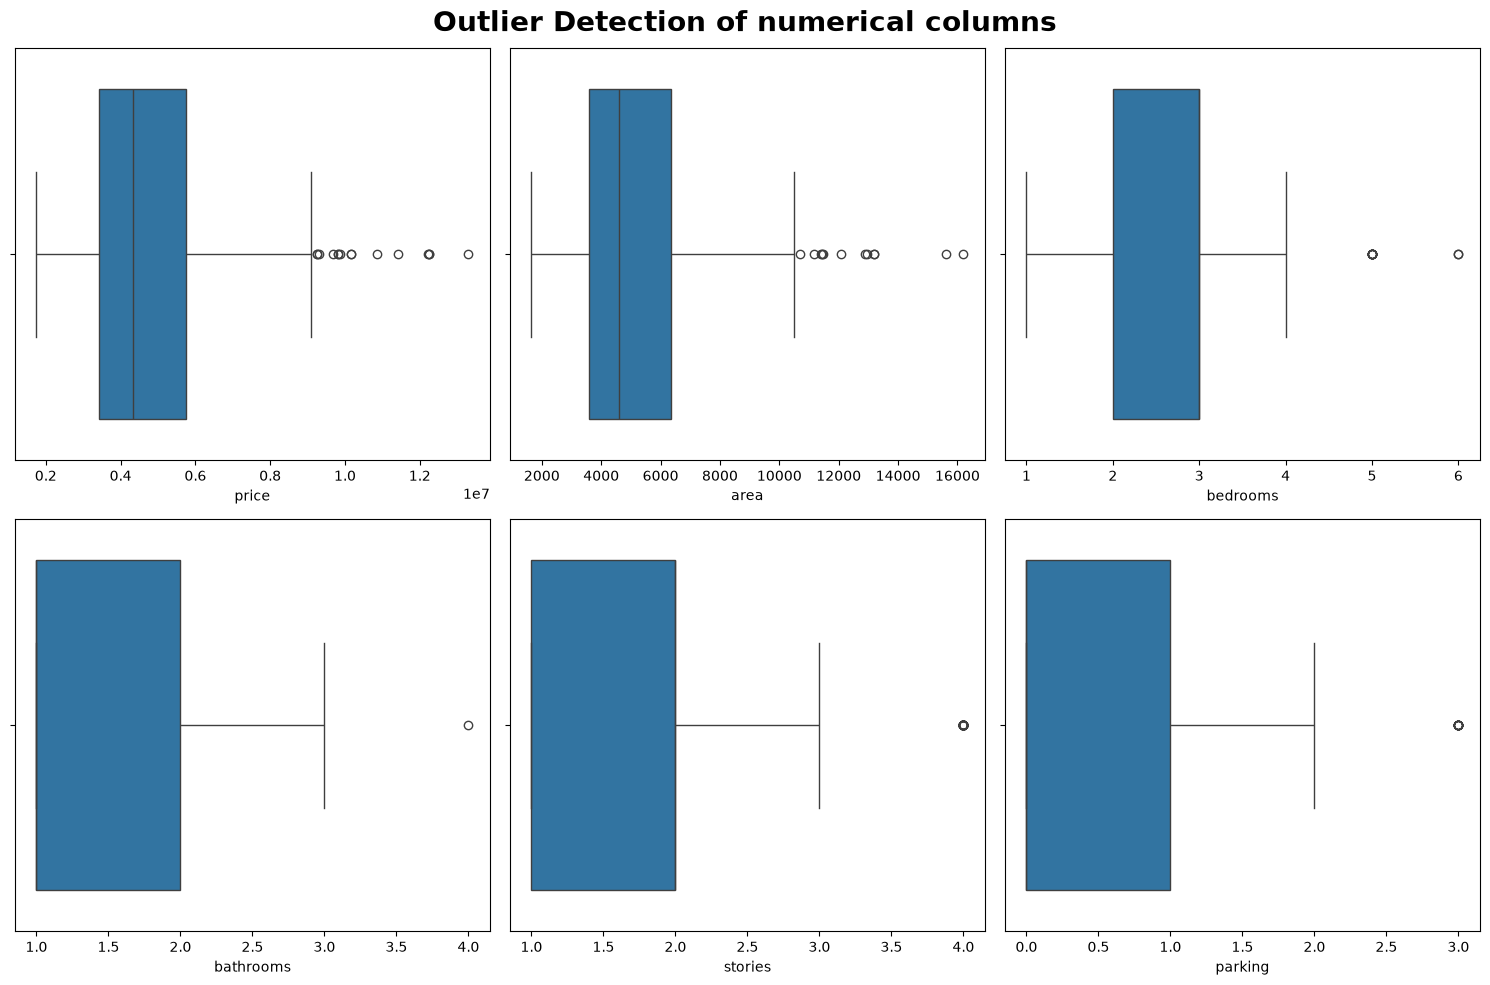

In [252]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.boxplot(
        data = df,
        x = col,
        ax = ax
    )

plt.suptitle('Outlier Detection of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [253]:
ft = FunctionTransformer(np.log1p)
df['price'] = ft.fit_transform(df['price'])
df['area'] = ft.fit_transform(df['area'])

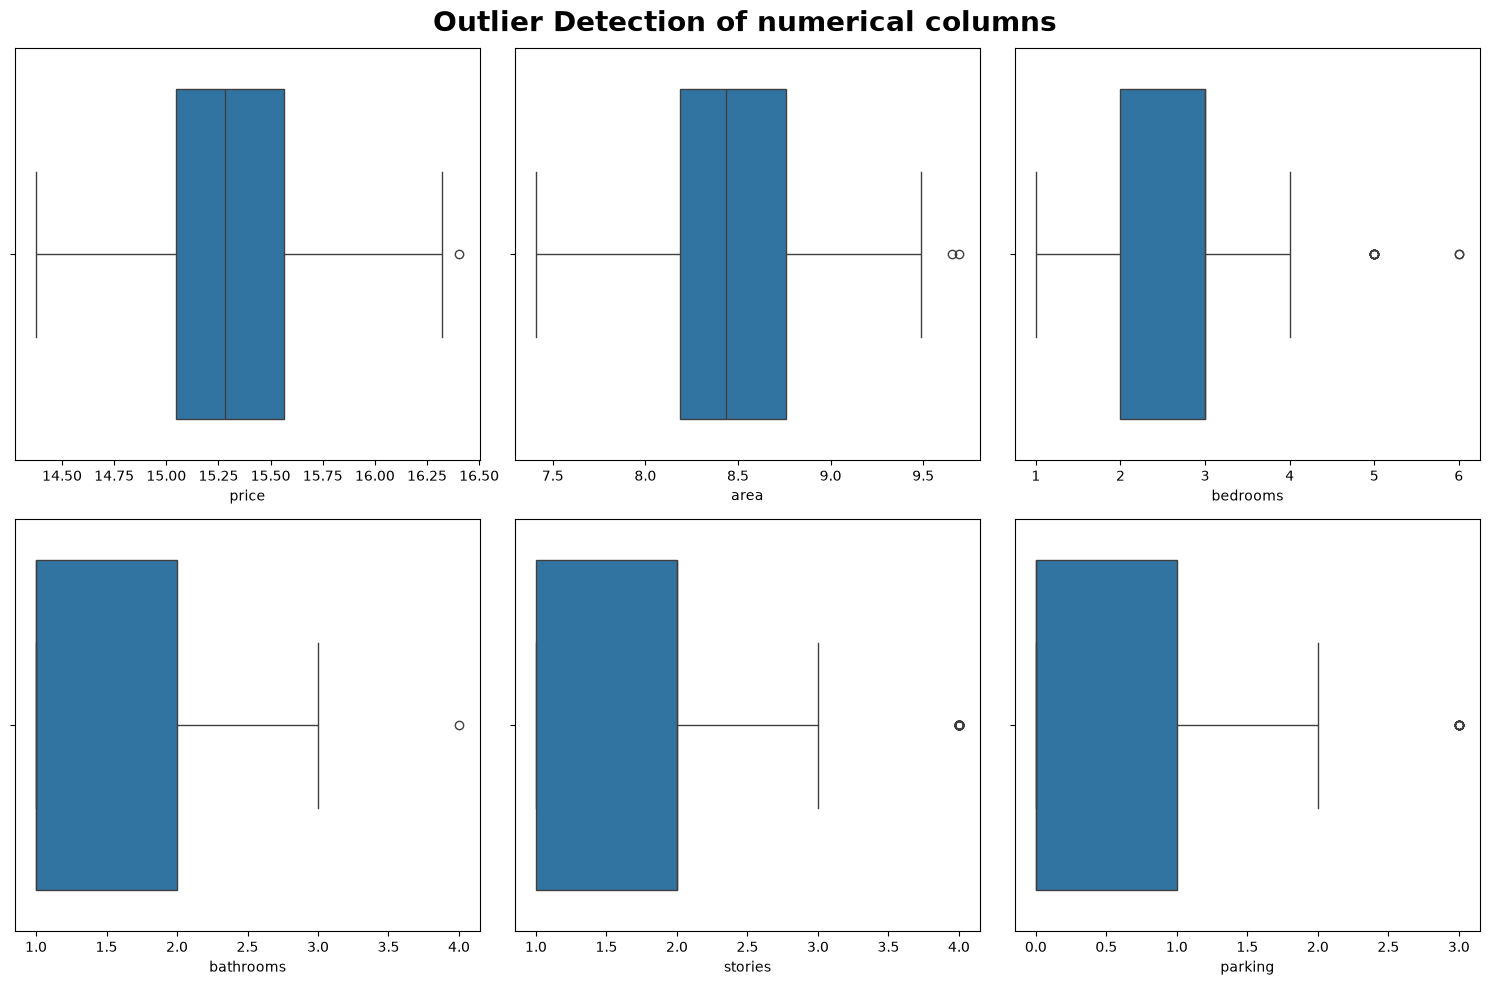

In [254]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.boxplot(
        data = df,
        x = col,
        ax = ax
    )

plt.suptitle('Outlier Detection of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

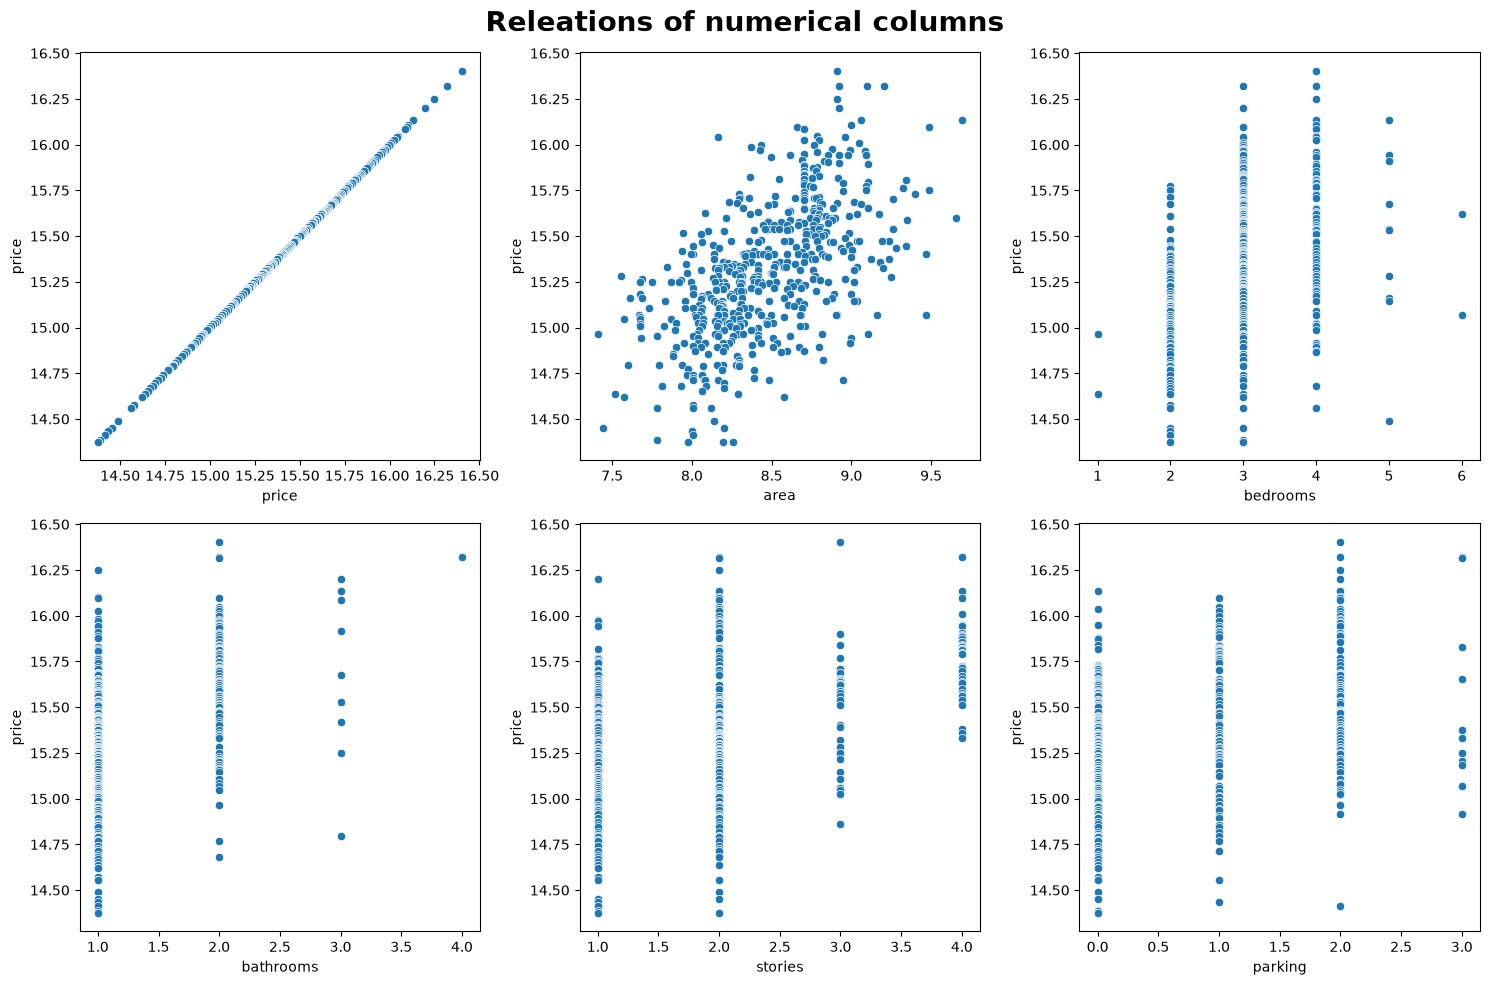

In [255]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]
    sns.scatterplot(
        data = df,
        x = col,
        y = 'price',
        ax = ax
    )

plt.suptitle('Releations of numerical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

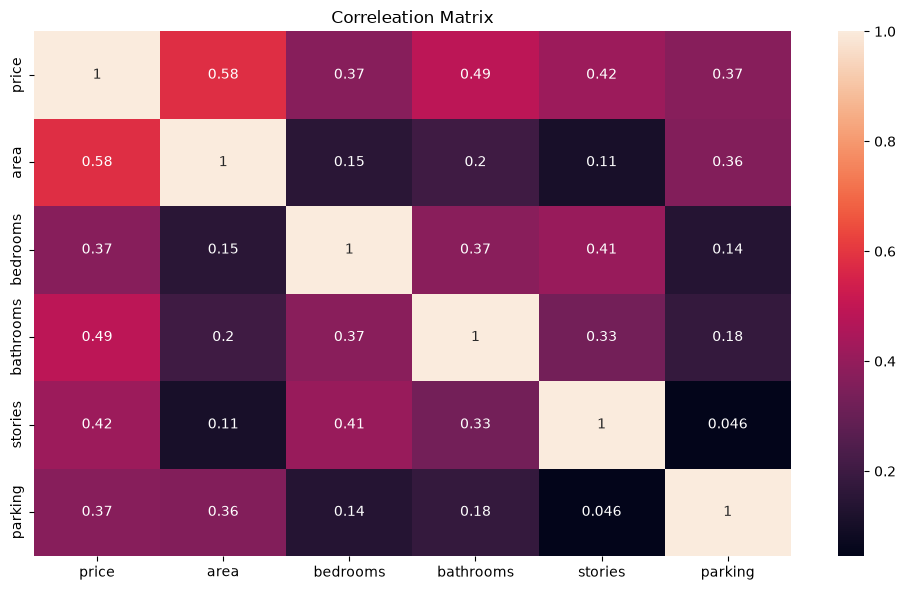

In [256]:
plt.figure(figsize = (10, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title('Correleation Matrix')
plt.tight_layout()
plt.show()

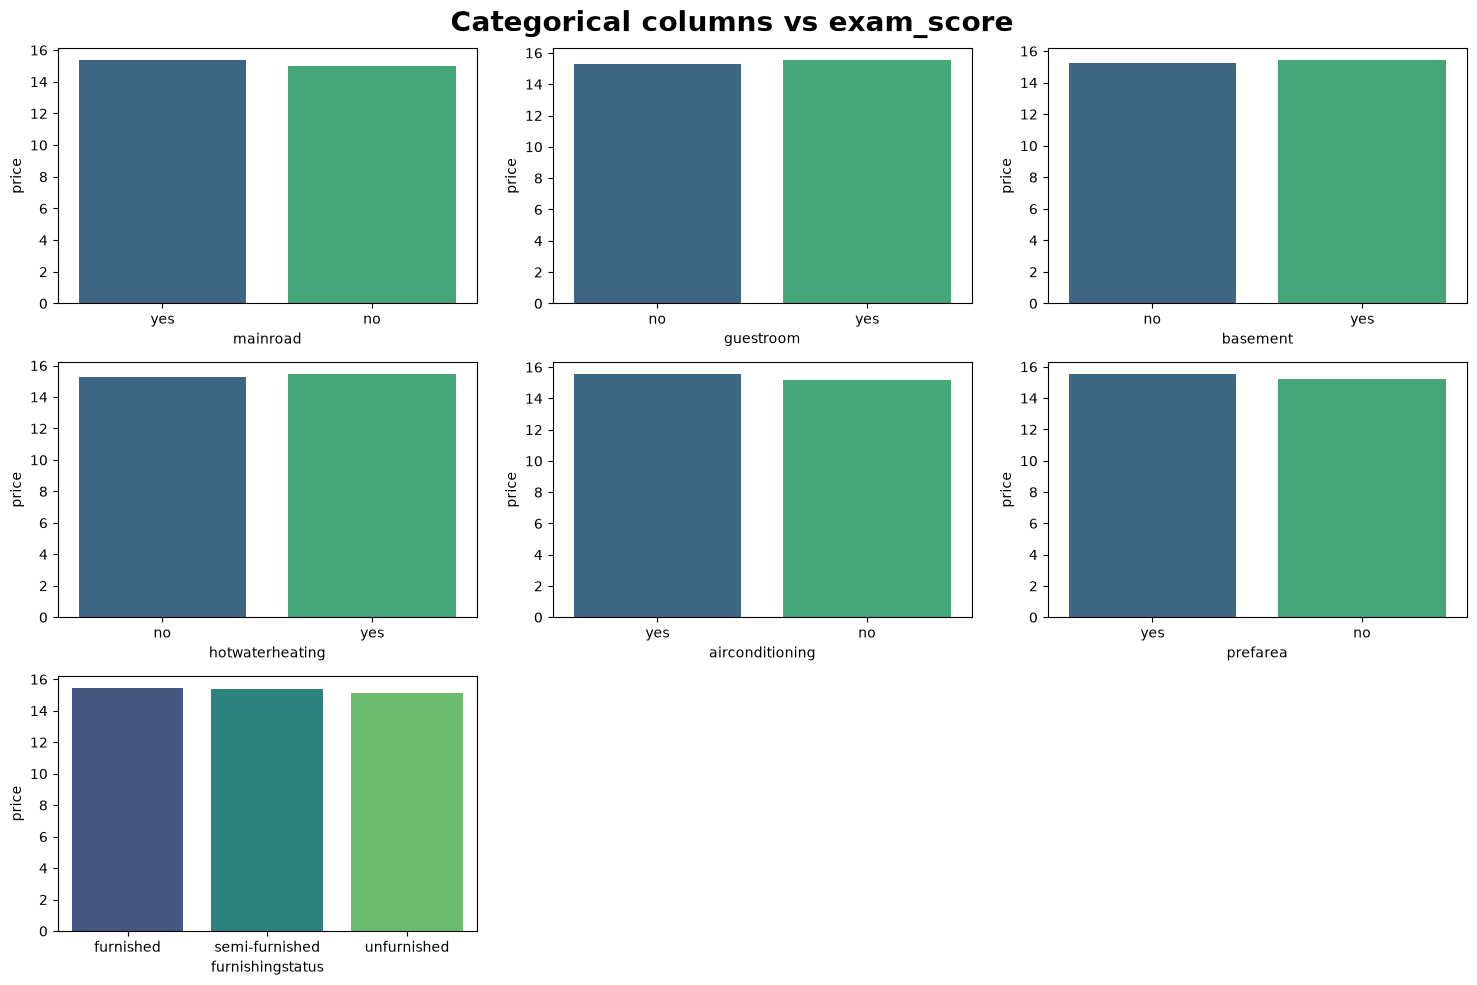

In [257]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    sns.barplot(
        data = df,
        x = col,
        y = 'price',
        ax = ax,
        palette = 'viridis',
        errorbar = None
    )


axes[7].remove()
axes[8].remove()
plt.suptitle('Categorical columns vs exam_score', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

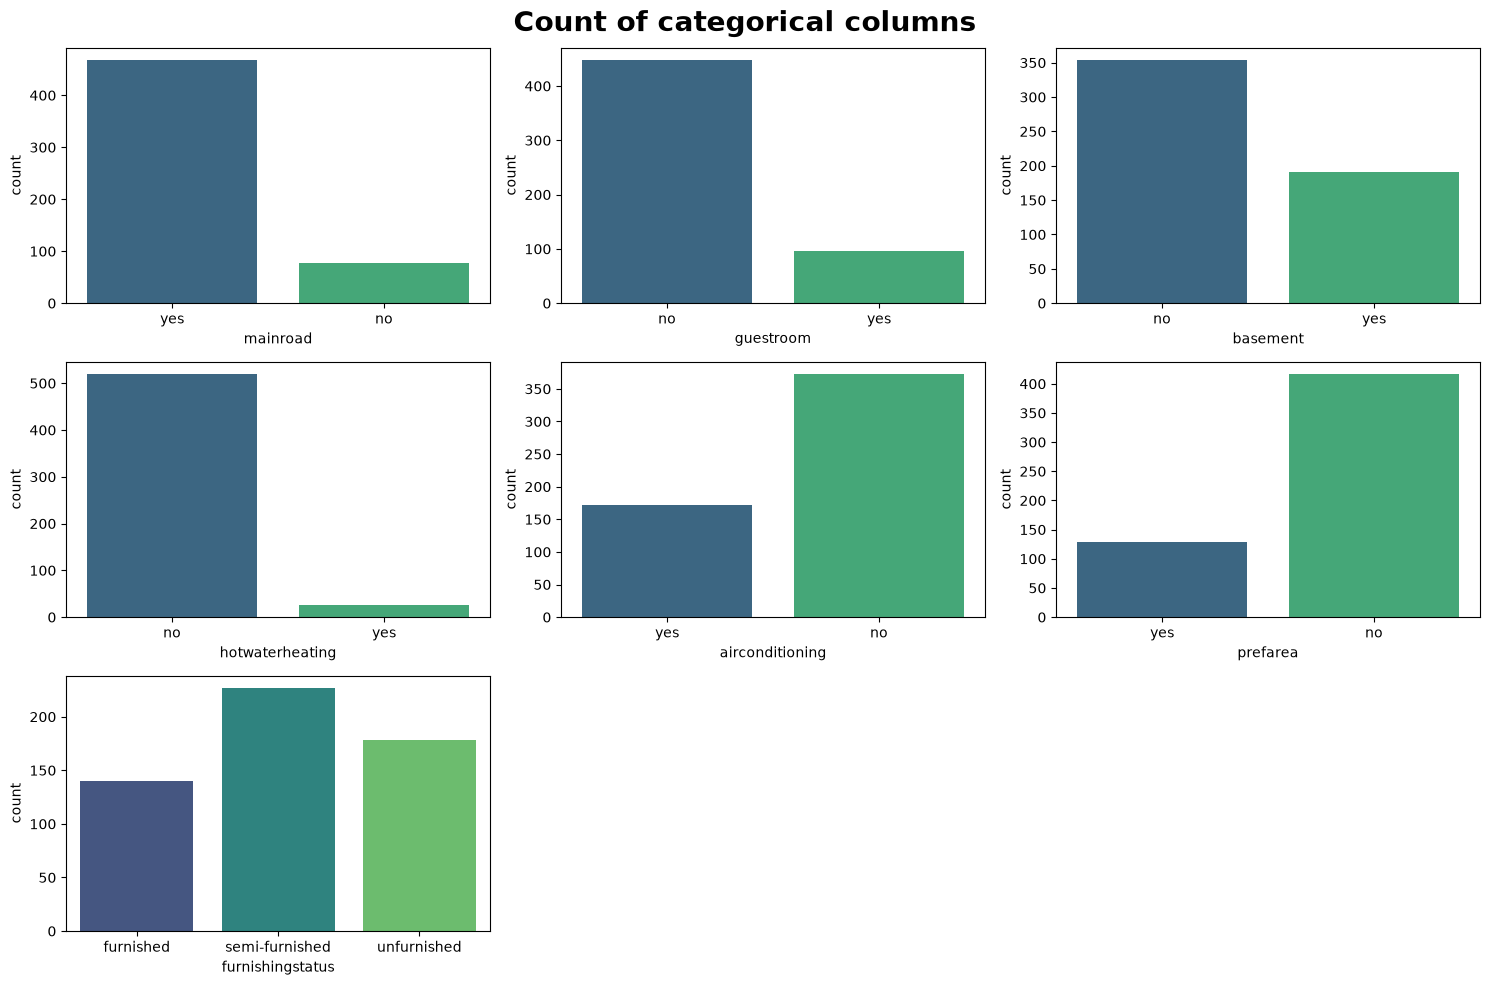

In [258]:
fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    sns.countplot(
        data = df,
        x = col,
        ax = ax,
        palette = 'viridis',
    )


axes[7].remove()
axes[8].remove()
plt.suptitle('Count of categorical columns', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [259]:
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished' : 3,
    'semi-furnished' : 2,
    'unfurnished' : 1
})

In [260]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [261]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,16.403275,8.912069,4,2,3,1,0,0,0,1,2,1,3
1,16.321037,9.100637,4,4,4,1,0,0,0,1,3,0,3
2,16.321037,9.206433,3,2,2,1,0,1,0,0,2,1,2
3,16.318175,8.922792,4,2,2,1,0,1,0,1,3,1,3
4,16.250001,8.912069,4,1,2,1,1,1,0,1,2,0,3


In [262]:
df[['bedrooms', 'bathrooms']] = df[['bedrooms', 'bathrooms']].astype(int)

In [263]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['price_per_sqft_area'] = df['price'] / df['area']
df['area_per_bedroom'] = df['area'] / (df['bedrooms'] + 1) 
df['area_per_room'] = df['area'] / (df['total_rooms'] + 1)

In [264]:
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,price_per_sqft_area,area_per_bedroom,area_per_room
0,16.403275,8.912069,4,2,3,1,0,0,0,1,2,1,3,6,1.840569,1.782414,1.273153
1,16.321037,9.100637,4,4,4,1,0,0,0,1,3,0,3,8,1.793395,1.820127,1.011182
2,16.321037,9.206433,3,2,2,1,0,1,0,0,2,1,2,5,1.772786,2.301608,1.534405


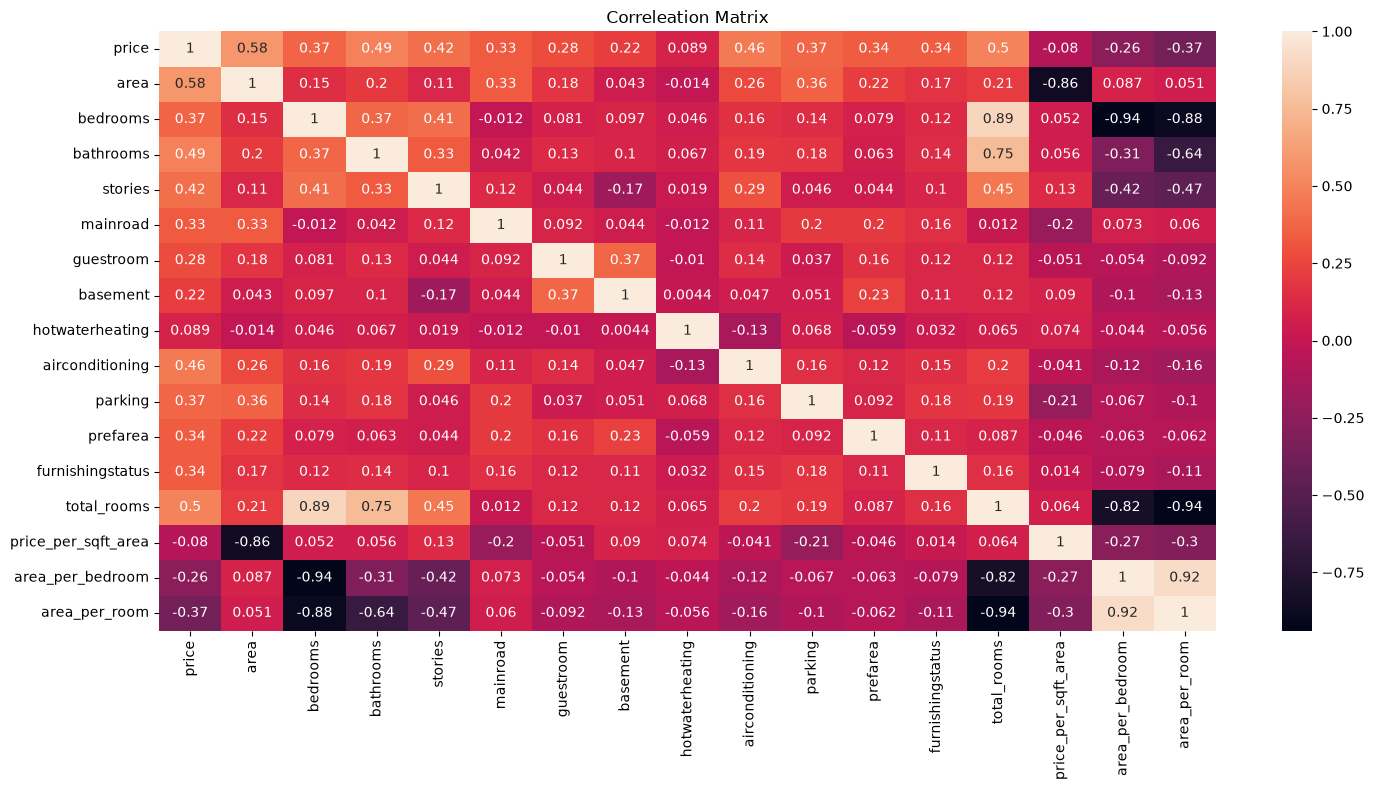

In [265]:
plt.figure(figsize = (15, 8))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.title('Correleation Matrix')
plt.tight_layout()
plt.show()

In [266]:
X = df.drop(columns = ['price'])
y = df['price']

In [267]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [268]:
lr = LinearRegression()

In [269]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ 1.77, 0.02,-0.02,..., 8.29, 0.1 ,-0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['area','bedrooms','bathrooms',...,'price_per_sqft_area', 'area_per_bedroom','area_per_room']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-14.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


## Train R2 Score

In [270]:
y_pred_train = lr.predict(X_train)

r2_score(y_train, y_pred_train)

0.989340476830846

## Test R2 Score

In [271]:
y_pred_test = lr.predict(X_test)

r2_score(y_test, y_pred_test)

0.9937476125876725